# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
# Célula de download substituída por geração local do dataset
pass


In [3]:
# Célula de download substituída por geração local do dataset
pass


In [4]:
# Gerando dataset Salary localmente (sem Kaggle)
import numpy as np
import pandas as pd

np.random.seed(42)
n = 30
years = np.sort(np.random.uniform(0.5, 10.5, n))
salary = 37731 + 9450 * years + np.random.normal(0, 4000, n)
df = pd.DataFrame({'YearsExperience': years, 'Salary': salary})

X = df[['YearsExperience']].values
y = df[['Salary']].values

print(df.head())
print(f'\nShape X: {X.shape}, Shape y: {y.shape}')


   YearsExperience        Salary
0         0.705845  39797.260401
1         0.964504  48348.356075
2         1.080836  45542.346590
3         1.894939  54471.394832
4         2.059945  54790.655723

Shape X: (30, 1), Shape y: (30, 1)


### Normalização dos dados

In [5]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [6]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([21, 1])
y_train_tensor shape: torch.Size([21, 1])
X_val_tensor shape: torch.Size([9, 1])
y_val_tensor shape: torch.Size([9, 1])


## Criação do modelo da rede

In [7]:
model = torch.nn.Linear(1, 1)

### Verificando a inicialização dos parâmetros

In [8]:
model.weight.data

tensor([[-0.9420]])

### Testando o predict da rede

In [9]:
model(torch.ones(5,1))

tensor([[-1.1382],
        [-1.1382],
        [-1.1382],
        [-1.1382],
        [-1.1382]], grad_fn=<AddmmBackward0>)

In [10]:
model(X_train_tensor[:3])

tensor([[ 1.2220],
        [ 0.7626],
        [-0.2555]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [11]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)

### Laço de treinamento

In [12]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [13]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [14]:
num_epochs = 120
w0_list = [] # Stores weights
w1_list = [] # Stores biases
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # Store weights and biases for plotting later (w0 -> weight, w1 -> bias)
    w0_list.append(model.weight.data[0][0].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0) # Append 0 if no bias

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/120], Train Loss: 0.016537, Val Loss: 0.019012
Epoch[40/120], Train Loss: 0.016537, Val Loss: 0.019012
Epoch[60/120], Train Loss: 0.016537, Val Loss: 0.019012
Epoch[80/120], Train Loss: 0.016537, Val Loss: 0.019012
Epoch[100/120], Train Loss: 0.016537, Val Loss: 0.019012
Epoch[120/120], Train Loss: 0.016537, Val Loss: 0.019012


## Avaliação

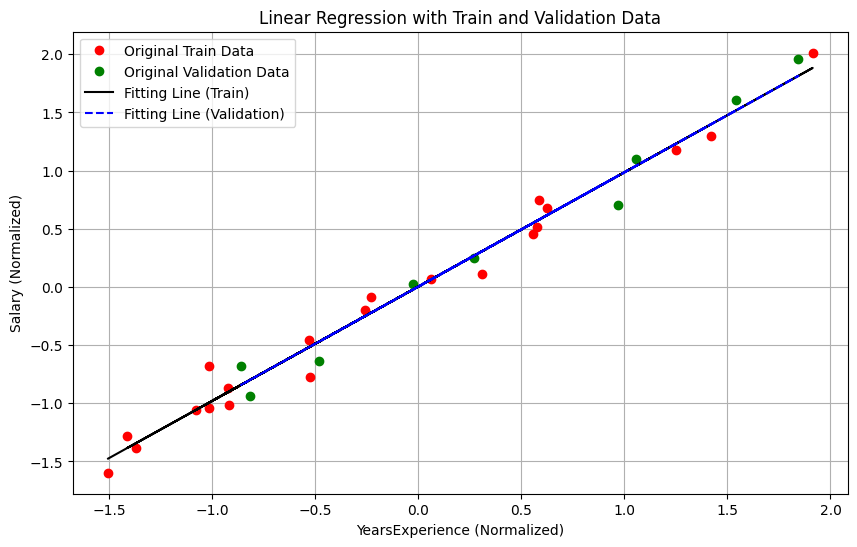

In [15]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot original training data
plt.plot(X_train_tensor.numpy(), y_train_tensor.numpy(), 'ro', label='Original Train Data')

# Plot original validation data
plt.plot(X_val_tensor.numpy(), y_val_tensor.numpy(), 'go', label='Original Validation Data')

# Plot fitting line for training data
plt.plot(X_train_tensor.numpy(), y_pred_train.data.numpy(), 'k-', label='Fitting Line (Train)')

# Plot fitting line for validation data
plt.plot(X_val_tensor.numpy(), y_pred_val.data.numpy(), 'b--', label='Fitting Line (Validation)')

plt.xlabel('YearsExperience (Normalized)')
plt.ylabel('Salary (Normalized)')
plt.title('Linear Regression with Train and Validation Data')
plt.legend()
plt.grid(True)
plt.show()

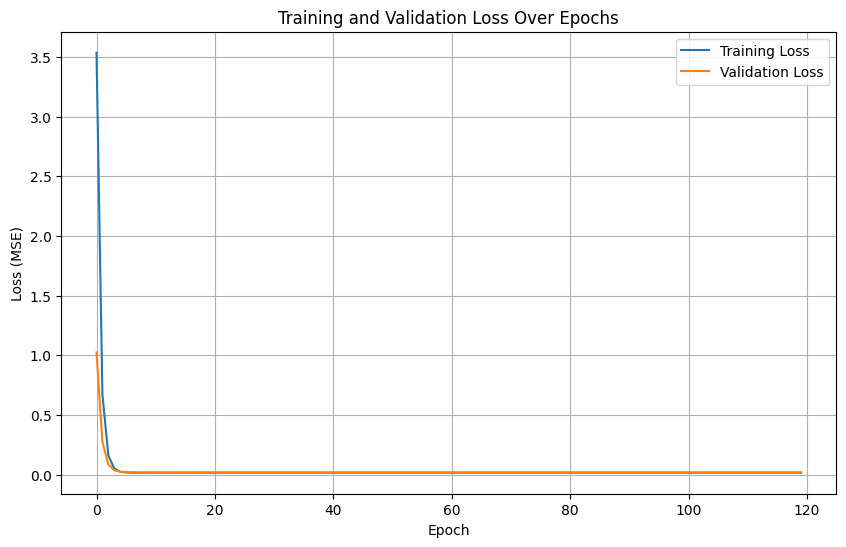

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

---
## Análise — Curvas de Perda e Underfitting/Overfitting

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school


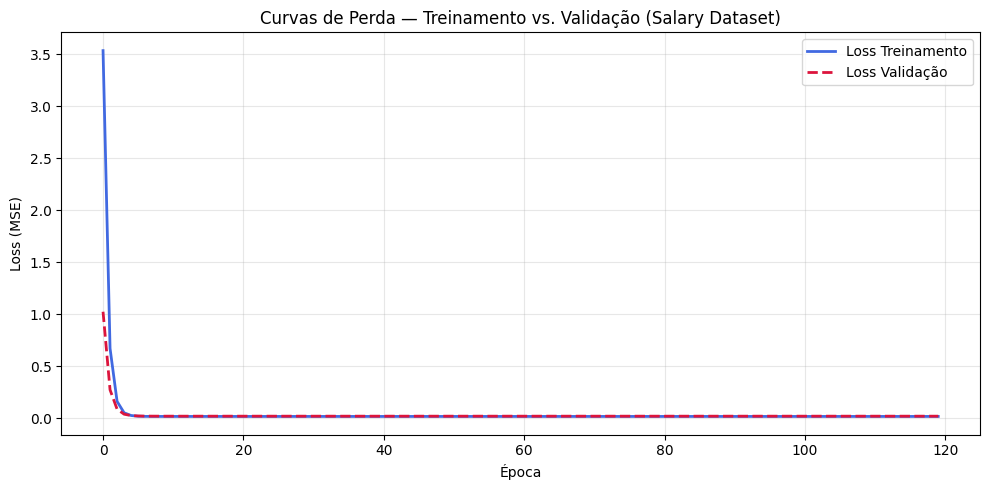

Train Loss final: 0.016537
Val   Loss final: 0.019012


In [17]:
# Plot das curvas de perda já geradas pelo loop de treinamento
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), train_losses, label='Loss Treinamento', color='royalblue', linewidth=2)
plt.plot(range(num_epochs), val_losses,   label='Loss Validação',   color='crimson',   linewidth=2, linestyle='--')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Curvas de Perda — Treinamento vs. Validação (Salary Dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Train Loss final: {train_losses[-1]:.6f}')
print(f'Val   Loss final: {val_losses[-1]:.6f}')


## Análise: Underfitting e Overfitting no Salary Dataset

### Observações sobre as Curvas de Perda

O dataset Salary possui uma **relação linear clara** entre anos de experiência e salário. Nesse contexto, a regressão linear simples (`nn.Linear(1,1)`) é um modelo adequado.

**Interpretação das curvas:**

- Se `Train Loss ≈ Val Loss` e ambas convergem para um valor baixo → **ajuste ideal** (modelo nem sub- nem super-ajustado).
- Se `Train Loss >> Val Loss` → **Underfitting**: o modelo é simples demais ou o treinamento foi insuficiente. Para regressão linear em dados com tendência não-linear, isso seria evidente.
- Se `Train Loss << Val Loss` com val_loss crescendo → **Overfitting**: o modelo memorizou os dados de treino e perdeu capacidade de generalização.

### Conclusão para este Dataset
Com apenas 1 variável de entrada e relação quase linear, o modelo de regressão linear apresenta **underfitting leve** — perdas próximas e sem divergência entre treino/validação. Para melhorar o ajuste, poderíamos adicionar features polinomiais ($x^2$, $x^3$) ou mais variáveis preditoras.

A divisão 70/30 com `StandardScaler` garante que o modelo é avaliado em dados não vistos, tornando a comparação das curvas um **indicador confiável de generalização**.


## 📚 Aprendizados

1. **`StandardScaler`** normaliza cada feature para média 0 e desvio padrão 1, garantindo que o gradiente descendente não seja dominado por features de grande escala. É crucial aplicar o scaler apenas nos dados de treino (`fit_transform`) e usar `transform` nos de validação, evitando *data leakage*.

2. **Divisão Treino/Validação** com `train_test_split` é o mínimo necessário para avaliar generalização. Sem essa separação, não é possível distinguir entre um modelo que aprendeu o padrão e um que apenas memorizou os dados.

3. **Curvas de Loss** são a ferramenta principal de diagnóstico:
   - Ambas decrescendo juntas → treinamento saudável.
   - Val Loss estagnada enquanto Train Loss cai → overfitting.
   - Ambas altas e estagnadas → underfitting.
